In [43]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import lissa as li

import statsmodels.api as sm

from sklearn.preprocessing import power_transform
from sklearn.preprocessing import RobustScaler, StandardScaler
import pickle

from sklearn.decomposition import PCA

In [6]:
PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

PCAHeaders = [str(i) for i in range(0,8)]

pumpList = PCAData["Well Run"].unique()


/tmp/ipykernel_238459/452915461.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [ ]:
pumpPropData = pd.DataFrame()
header = [
    "varX",
    "varY",
    "varR",
    "meanX",
    "meanY",
    "meanR",
    "energyX",
    "energyY",
    "energyR"]
for pump in pumpList:
    pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

    #li.PCAComponentsPlot(pumpData,pump,PCAHeaders)
    #pumpData["ESP Vibration X"].plot(figsize=(20,10))
    pumpData["Shutdown"] = (pumpData["Well_down"] != pumpData["Well_down"].shift(1).fillna(pumpData["Well_down"].iloc[-1])) #differentiates well down blocks

    pumpData["CumShut"] = pumpData["Shutdown"].cumsum() #group names them

    testSize =pumpData.groupby("CumShut") #groupby execution

    var = testSize[["ESP Vibration X","ESP Vibration Y","Radius"]].var()
    mean = testSize[["ESP Vibration X","ESP Vibration Y","Radius"]].mean()
    energy = testSize[["ESP Vibration X","ESP Vibration Y","Radius"]].apply(lambda x: (x**2).sum())

    propData = pd.concat([var,mean,energy],axis=1)
    propData.columns = [
        "varX",
        "varY",
        "varR",
        "meanX",
        "meanY",
        "meanR",
        "energyX",
        "energyY",
        "energyR"]

    RobustScaler().fit_transform(propData)
    propData["Well Run"] = pump


    pumpPropData = pd.concat([pumpPropData,propData])


<Axes: >

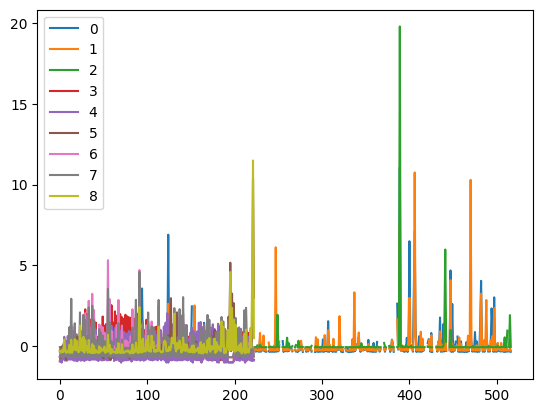

In [83]:
pump = pumpList[0]
pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#li.PCAComponentsPlot(pumpData,pump,PCAHeaders)
#pumpData["ESP Vibration X"].plot(figsize=(20,10))
pumpData["Shutdown"] = (pumpData["Well_down"] != pumpData["Well_down"].shift(1).fillna(pumpData["Well_down"].iloc[-1])) #differentiates well down blocks

pumpData["CumShut"] = pumpData["Shutdown"].cumsum() #group names them

testSize =pumpData.groupby("CumShut") #groupby execution

std = testSize[["ESP Vibration X","ESP Vibration Y","Radius"]].std()
mean = testSize[["ESP Vibration X","ESP Vibration Y","Radius"]].mean()
energy = testSize[["ESP Vibration X","ESP Vibration Y","Radius"]].apply(lambda x: (x**2).sum().pow(1/2))


propData = pd.concat([var,mean,energy],axis=1)
propData.columns = [
    "stdX",
    "stdY",
    "stdR",
    "meanX",
    "meanY",
    "meanR",
    "energyX",
    "energyY",
    "energyR"]
pd.DataFrame(StandardScaler().fit_transform(propData)).plot()
# propData["Well Run"] = pump

# pumpPropData = pd.concat([pumpPropData,propData])

<Axes: xlabel='CumShut'>

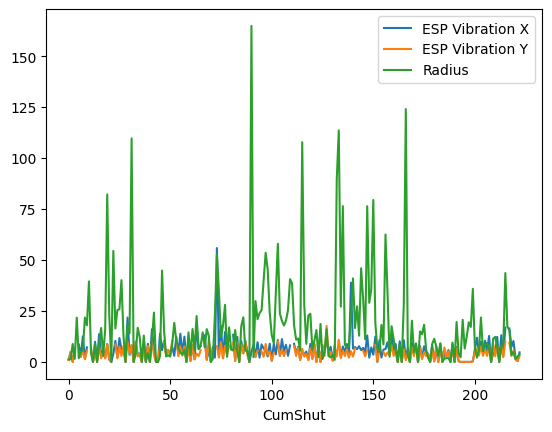

In [85]:
(mean/std).fillna(0).plot()

array([[<Axes: title={'center': 'varX'}>,
        <Axes: title={'center': 'varY'}>,
        <Axes: title={'center': 'varR'}>],
       [<Axes: title={'center': 'meanX'}>,
        <Axes: title={'center': 'meanY'}>,
        <Axes: title={'center': 'meanR'}>],
       [<Axes: title={'center': 'energyX'}>,
        <Axes: title={'center': 'energyY'}>,
        <Axes: title={'center': 'energyR'}>]], dtype=object)

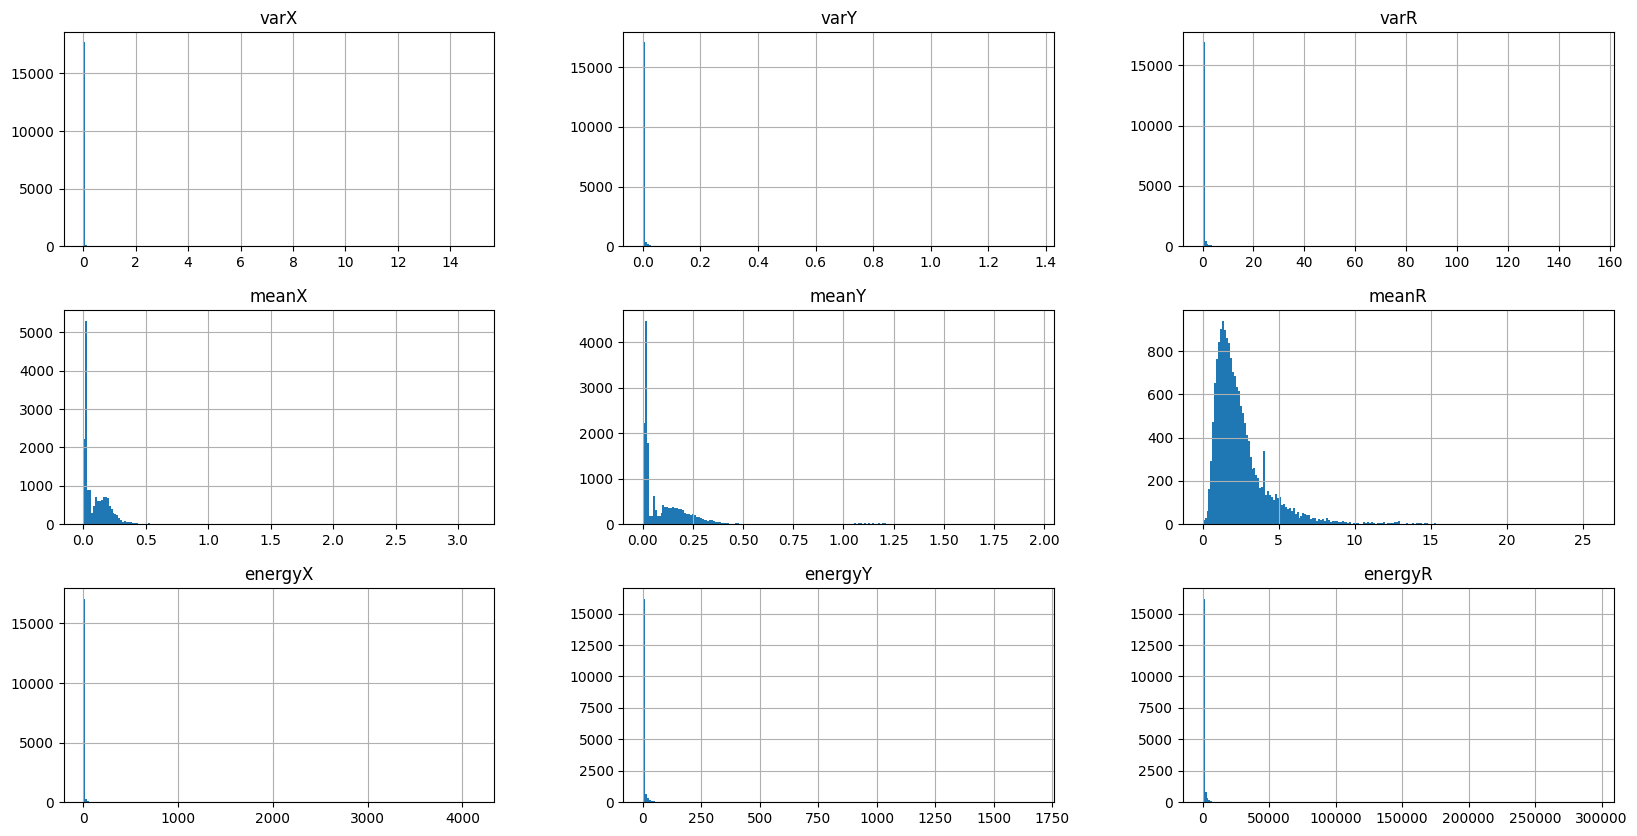

In [100]:
pumpPropData.hist(figsize=(20,10),bins=200)

In [33]:
#normalizar
#aplicar PCA
#enxergar padrões
#tentar também com t-sne

pca = PCA(n_components=2)
pumpPropData.fillna(0,inplace=True)
PCAzed = pd.DataFrame(pca.fit_transform(RobustScaler().fit_transform(pumpPropData[header])))



<Axes: >

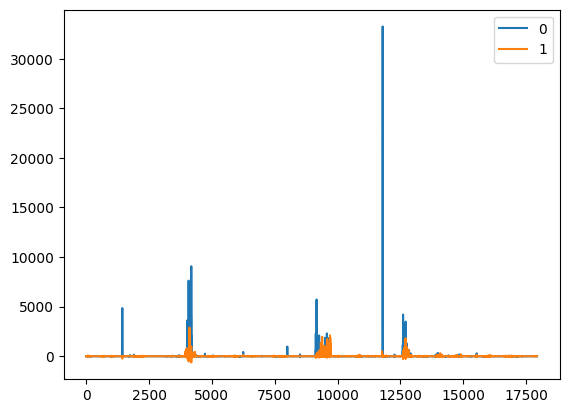

In [34]:
PCAzed.plot()